In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import time
import os
import sys

from Data_Pull import *
from Costs import *
from PCA_OU import *
from Dashboard import *

In [2]:
# # Pull/combine/save yfinance data (long)
# yfinance_chunk_pull()
# combine_yfinance_chunks()

# # Or read a previously saved copy
# data = pd.read_parquet(os.path.join('data','yfinance_selected.parquet'))

# # Build characteristics (eg. monthly returns)
# returns, chars = build_characteristics(data)

# # Build/Save as numpy tensor
# X, R, mask, dates, tickers, char_order = chars_dict_to_tensor(chars,returns)

In [3]:
# For specific K number of PCA factors (faster than computing a grid of K values)

data_path = os.path.join('data','data_tensors.npz')
data = load_data(data_path)
R, mask, dates = data["R"], data["mask"], data["dates"]

eval_start_date = "1998-01-01"
eval_start_idx = find_eval_start(dates, eval_start_date)

# K = 5 is the optimal (after running the grid below)
row, result = run_one_K(R, mask, dates, eval_start_idx, 5, verbose=True)


--- K = 5 ---
  t=0/6292  active=32  gross_today=+0.0129
  t=252/6292  active=39  gross_today=+0.0000
  t=504/6292  active=27  gross_today=+0.0115
  t=756/6292  active=44  gross_today=-0.0028
  t=1008/6292  active=48  gross_today=-0.0075
  t=1260/6292  active=47  gross_today=+0.0046
  t=1512/6292  active=32  gross_today=-0.0059
  t=1764/6292  active=29  gross_today=-0.0019
  t=2016/6292  active=28  gross_today=-0.0014
  t=2268/6292  active=26  gross_today=-0.0068
  t=2520/6292  active=35  gross_today=+0.0022
  t=2772/6292  active=50  gross_today=+0.0020
  t=3024/6292  active=44  gross_today=+0.0019
  t=3276/6292  active=39  gross_today=+0.0040
  t=3528/6292  active=41  gross_today=+0.0000
  t=3780/6292  active=34  gross_today=+0.0001
  t=4032/6292  active=36  gross_today=+0.0048
  t=4284/6292  active=37  gross_today=-0.0042
  t=4536/6292  active=45  gross_today=-0.0017
  t=4788/6292  active=48  gross_today=-0.0066
  t=5040/6292  active=49  gross_today=+0.0010
  t=5292/6292  active=52 

In [7]:
# Benchmark "Equal-Weighted Buy and Hold"
benchmark_rets = benchmark_returns(result, R, mask, eval_start_idx)
benchmark_m = annualized_metrics(benchmark_rets)
print(f'Equal-Weighted Benchmark Sharpe: {benchmark_m['sharpe']}')

Equal-Weighted Benchmark Sharpe: 0.9062964878810122


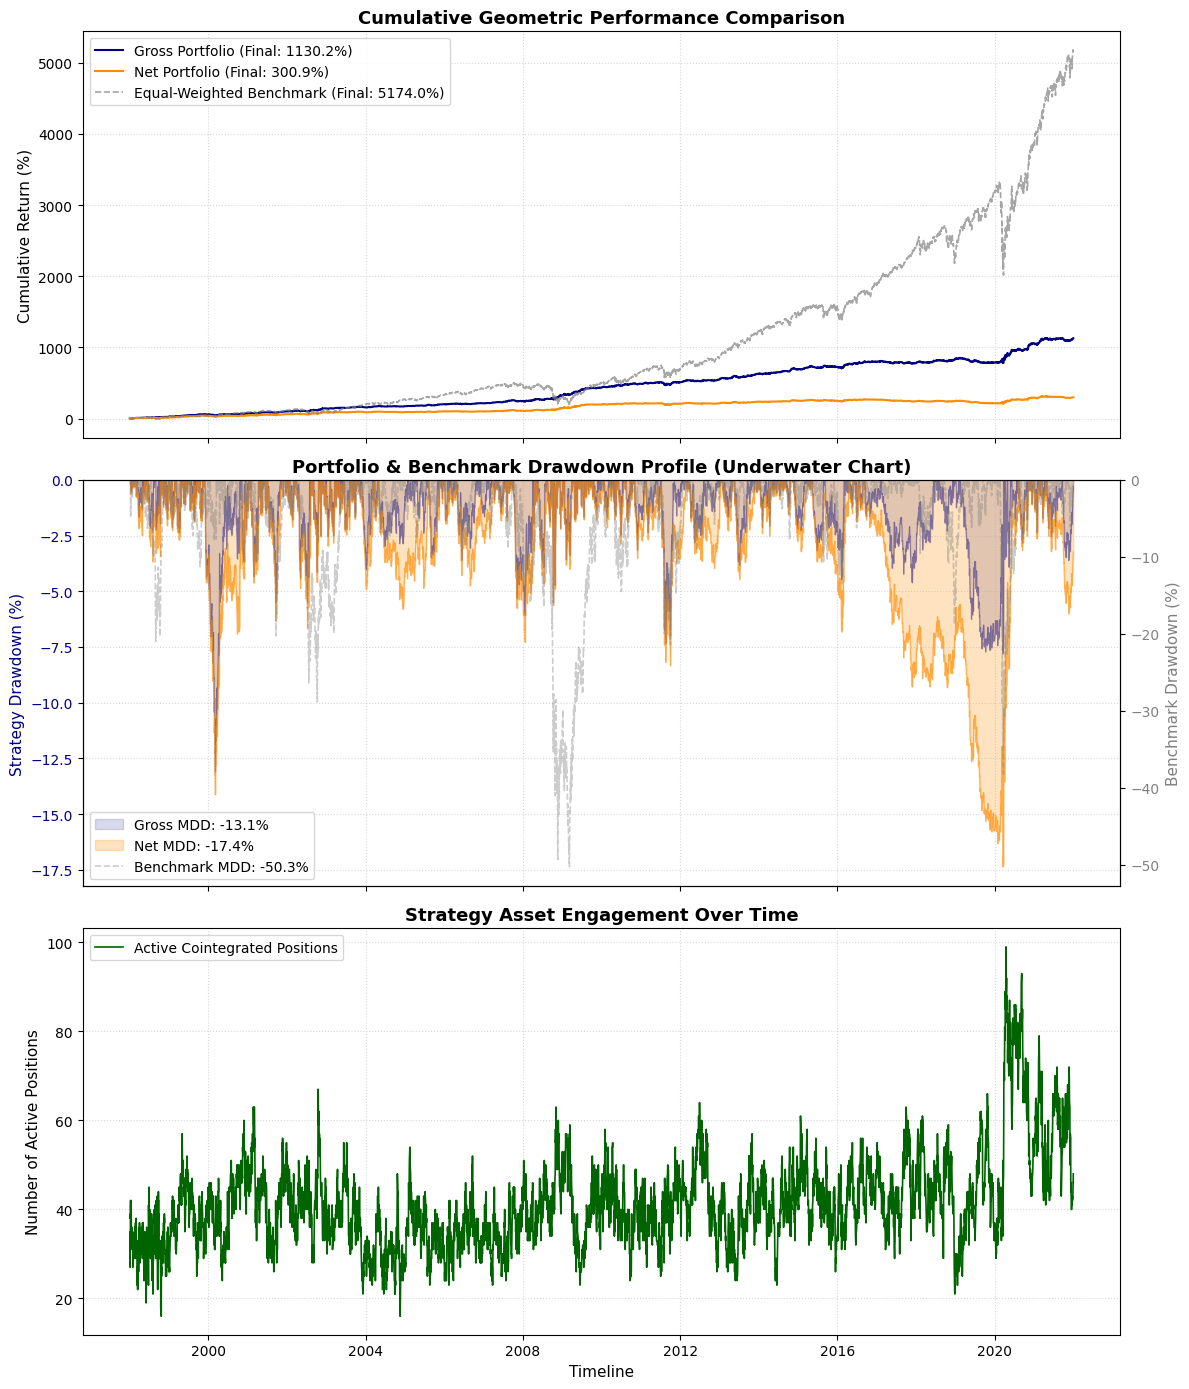

         INSTITUTIONAL PERFORMANCE SUMMARY       
Maximum Gross Drawdown:  -13.11%
Maximum Net Drawdown:    -17.37%
Maximum Bench Drawdown:  -50.26%
Terminal Net Return:     300.94%


In [8]:
# Generate and save the 3-panel dashboard
gross_dd, net_dd, benchmark_dd = generate_performance_dashboard(
    result=result,
    net_returns=result['net_returns'],
    benchmark_rets=benchmark_rets,
    save_path="optimal_k5_dashboard.png"
)

In [ ]:
# Run PCA/OU Model for Grid of K Values (saved printout in data folder)
# Default parameters is K in [1,3,5,8,15,30]
metrics, results = train_pca_model(os.path.join('data','data_tensors.npz'))